In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from pydub import AudioSegment
from pydub.utils import which
from sklearn.model_selection import train_test_split

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


**DATASET - RAVDESS**


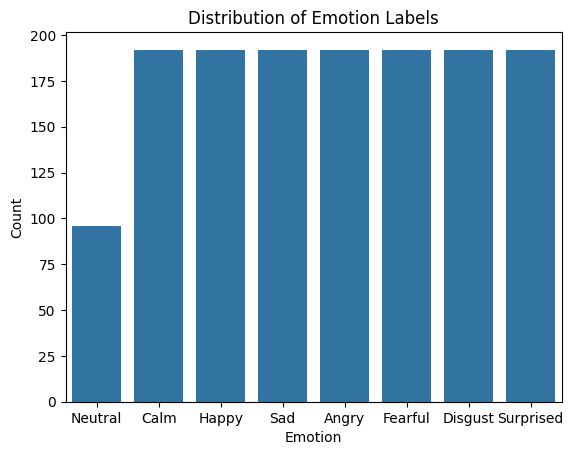

In [2]:
Ravdess = "dataset\\ravdess\\"

data = []

emotion_map = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised",
}

for dir in os.listdir(Ravdess):
    for file in os.listdir(os.path.join(Ravdess, dir)):
        filename, _ = os.path.splitext(file)
        parts = filename.split("-")
        emotion_code = int(parts[2])
        emotion = emotion_map.get(emotion_code, "Unknown")
        path = os.path.join(Ravdess, dir, file)
        data.append([path, emotion])

Ravdess_df = pd.DataFrame(data, columns=["path", "emotion"])

sns.countplot(x=Ravdess_df["emotion"])
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

**CREMA-D**

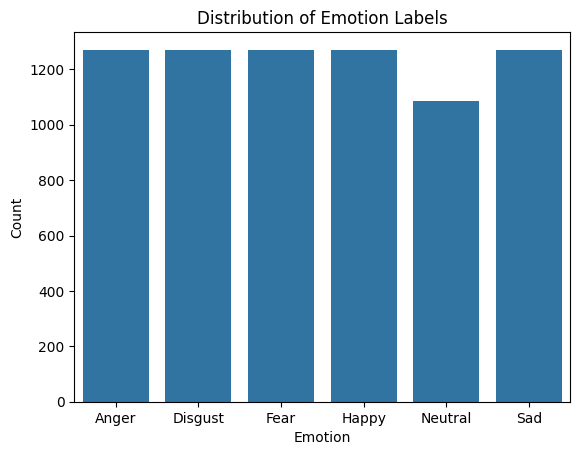

In [7]:
CremaD = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    'ANG': "Anger",
    'DIS': "Disgust",
    'FEA': "Fear",
    'HAP': "Happy",
    'NEU': "Neutral",
    'SAD': "Sad",
}

# Anger, Disgust, Fear, Happy, Neutral, and Sad

for file in os.listdir(CremaD):
    filename, _ = os.path.splitext(file)
    parts = filename.split("_")
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")
    path = os.path.join(CremaD, file)
    data.append([path, emotion])

CremaD_df = pd.DataFrame(data, columns=["path", "emotion"])

sns.countplot(x=CremaD_df["emotion"])
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

**Output Dataframe to CSV**


In [8]:
def create_csv(df: pd.DataFrame, filename: str):
    csv_dir = "CSVs\\"

    if not os.path.exists(csv_dir):
        os.makedirs(csv_dir)
        print(f"Directory {csv_dir} created.")

    df.to_csv(os.path.join(csv_dir, filename), index=False)

    print(f"CSV file created at: {os.path.join(csv_dir, filename)}")


# create_csv(Ravdess_df, "ravdess.csv")
create_csv(CremaD_df, "cremad.csv")

CSV file created at: CSVs\cremad.csv


**Silence Removal**


In [9]:
AudioSegment.converter = which("ffmpeg")

dataset = pd.read_csv("CSVs\\cremad.csv")

location = "cremad_Silence\\"


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Error processing {row['path']}, saved original audio.")

    file_data.append([file_name, row["emotion"]])
    name += 1

CremaD_silence = pd.DataFrame(file_data, columns=["path", "emotion"])
create_csv(CremaD_silence, "cremad_silence_removed.csv")

Error processing dataset\CREMA-D\AudioWAV\1076_MTI_SAD_XX.wav, saved original audio.
CSV file created at: CSVs\cremad_silence_removed.csv


**Dataset partitioning**


In [10]:
cremad_augmented = pd.read_csv("CSVs\\cremad_silence_removed.csv")
X = cremad_augmented["path"]
y = cremad_augmented["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

create_csv(pd.DataFrame({"path": X_train, "emotion": y_train}), "cremad_train.csv")
create_csv(pd.DataFrame({"path": X_val, "emotion": y_val}), "cremad_val.csv")
create_csv(pd.DataFrame({"path": X_test, "emotion": y_test}), "cremad_test.csv")

Train: 5953, Val: 744, Test: 745
CSV file created at: CSVs\cremad_train.csv
CSV file created at: CSVs\cremad_val.csv
CSV file created at: CSVs\cremad_test.csv


**Data augmentation**


In [11]:
cremad_train = pd.read_csv("CSVs\\cremad_train.csv")
location = "cremad_Augmented\\"
os.makedirs(location, exist_ok=True)

def noise(n_data):
    noise_amp = 0.04 * np.random.uniform() * np.amax(n_data)
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = 0.8
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = 0.7
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

for _, row in cremad_train.iterrows():
    # Original audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data, sampling_rate = librosa.load(row["path"])
    sf.write(file_name, data, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Noise augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_noise = noise(data)
    sf.write(file_name, data_noise, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Time stretch augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_stretch = stretch(data)
    sf.write(file_name, data_stretch, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Pitch augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_pitch = pitch(data, sampling_rate)
    sf.write(file_name, data_pitch, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1


CremaD_augmented = pd.DataFrame(file_data, columns=["path", "emotion"])
create_csv(CremaD_augmented, "cremad_augmented.csv")

Processing cremad_Augmented\0.wav
Processing cremad_Augmented\1.wav
Processing cremad_Augmented\2.wav
Processing cremad_Augmented\3.wav
Processing cremad_Augmented\4.wav
Processing cremad_Augmented\5.wav
Processing cremad_Augmented\6.wav
Processing cremad_Augmented\7.wav
Processing cremad_Augmented\8.wav
Processing cremad_Augmented\9.wav
Processing cremad_Augmented\10.wav
Processing cremad_Augmented\11.wav
Processing cremad_Augmented\12.wav
Processing cremad_Augmented\13.wav
Processing cremad_Augmented\14.wav
Processing cremad_Augmented\15.wav
Processing cremad_Augmented\16.wav
Processing cremad_Augmented\17.wav
Processing cremad_Augmented\18.wav
Processing cremad_Augmented\19.wav
Processing cremad_Augmented\20.wav
Processing cremad_Augmented\21.wav
Processing cremad_Augmented\22.wav
Processing cremad_Augmented\23.wav
Processing cremad_Augmented\24.wav
Processing cremad_Augmented\25.wav
Processing cremad_Augmented\26.wav
Processing cremad_Augmented\27.wav
Processing cremad_Augmented\28